# Breast cancer prognosis

#### Import libraries

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from scipy.stats import wilcoxon

from sklearn.cluster import KMeans
from sklearn.decomposition import KernelPCA

## Data import and preprocessing

In [24]:
# Data import 
repoinfo = fetch_ucirepo(id=16)
X = repoinfo.data.features.values.astype(float)
y = repoinfo.data.targets.values.ravel()

# handle missing values in X(replace with column mean)
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# scale transform the values in X
scaler = StandardScaler()
Xt = scaler.fit_transform(X)

# encode y labels to numbers if they are strings
le = LabelEncoder()
yt = le.fit_transform(y)

# confirm everything looks right
print(Xt.shape)
print(yt.shape)
print(np.unique(y, return_counts=True))
print(y[-10:], yt[-10:])
print(np.mean(X, axis=0))  ## original data mean
print("Normalized values are zero except for roundoff errors:")
print(np.mean(Xt, axis=0)) ## normalized data mean
print(np.std(X, axis=0))  ## original data scale 
print(np.std(Xt, axis=0)) ## normalized data scale

(198, 33)
(198,)
(array(['N', 'R'], dtype=object), array([151,  47]))
['N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'R' 'N'] [0 0 0 0 0 0 0 0 1 0]
[4.67323232e+01 1.74123232e+01 2.22760101e+01 1.14856566e+02
 9.70040909e+02 1.02681414e-01 1.42647778e-01 1.56242778e-01
 8.67756061e-02 1.92754040e-01 6.27055051e-02 6.03346465e-01
 1.26445000e+00 4.25539394e+00 7.02287374e+01 6.76186364e-03
 3.11992929e-02 4.07497980e-02 1.50992525e-02 2.05548586e-02
 3.98690404e-03 2.10218182e+01 3.01390909e+01 1.40347778e+02
 1.40495859e+03 1.43920758e-01 3.65101818e-01 4.36685303e-01
 1.78777525e-01 3.23404040e-01 9.08281313e-02 2.84747475e+00
 3.21134021e+00]
Normalized values are zero except for roundoff errors:
[-3.58859968e-17 -9.15092917e-16  7.89491929e-16  3.05030972e-16
  4.48574959e-16 -1.34572488e-16  3.36431220e-16  2.78116475e-16
  6.36976442e-16 -8.79206921e-16 -4.30631961e-16  1.97372982e-16
 -5.83147447e-16  3.58859968e-17  0.00000000e+00 -2.28773229e-16
  1.52515486e-16  1.77187109e-16 -4.66517958e-

## Classification

### K-nearest neighbor and Gaussian process classifier hyperparametrization

In [ ]:
# Number of runs

N_RUNS      = 10
OUTER_FOLDS = 5
INNER_FOLDS = 5

# Parameter grids
# knn - k and metric
knn_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "metric":      ["euclidean", "manhattan"],
}
# gpc - kernel functions
gpc_grid = {
    "kernel": [RBF(), Matern(),RationalQuadratic(),DotProduct()],
}

# Storage
knn_accs, gpc_accs   = [], []
knn_preds, knn_ks, knn_mets   = [], [], []
gpc_preds, gpc_kf              = [], []
knn_true, gpc_true = [], []

rng = np.random.default_rng()

for run in range(N_RUNS):
    # Random permutation
    perm   = rng.permutation(len(y))
    X_p, y_p = X[perm], y[perm]

    outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True,
                               random_state=int(rng.integers(1e6)))
    inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True,
                               random_state=int(rng.integers(1e6)))

    # KNN cross validation 
    knn_base  = KNeighborsClassifier()
    knn_inner = GridSearchCV(knn_base, knn_grid, cv=inner_cv,
                             scoring="balanced_accuracy", n_jobs = -1)

    fold_knn_preds, fold_accs, fold_ks, fold_ms, fold_true_knn = [], [], [], [], []
    for train_idx, test_idx in outer_cv.split(X_p, y_p):
        knn_inner.fit(X_p[train_idx], y_p[train_idx])
        fold_knn_preds.append(knn_inner.predict(X_p[test_idx]))  # predict labels
        fold_accs.append(np.mean(fold_knn_preds[-1] == y_p[test_idx])) # calculate accuracy
        fold_true_knn.append(y_p[test_idx])
        fold_ks.append(knn_inner.best_params_["n_neighbors"])
        fold_ms.append(knn_inner.best_params_["metric"])

    knn_accs.append(np.mean(fold_accs))
    knn_preds.append(np.concatenate(fold_knn_preds))
    knn_ks.append(np.mean(fold_ks))         
    # most-frequent metric across folds
    knn_mets.append(max(set(fold_ms), key=fold_ms.count))
    knn_true.append(np.concatenate(fold_true_knn))

    # GPC cross validation 
    gpc_base  = GaussianProcessClassifier()
    gpc_inner = GridSearchCV(gpc_base, gpc_grid, cv=inner_cv,
                             scoring="balanced_accuracy", n_jobs = -1)

    fold_gpc_preds, fold_accs_g, fold_kf, fold_true_g = [], [], [], []
    for train_idx, test_idx in outer_cv.split(X_p, y_p):
        gpc_inner.fit(X_p[train_idx], y_p[train_idx])
        fold_gpc_preds.append(gpc_inner.predict(X_p[test_idx]))
        fold_accs_g.append(np.mean(fold_gpc_preds[-1] == y_p[test_idx]))
        fold_true_g.append(y_p[test_idx])
        fold_kf.append((type(gpc_inner.best_params_["kernel"]).__name__))

    gpc_accs.append(np.mean(fold_accs_g))
    gpc_preds.append(np.concatenate(fold_gpc_preds))
    gpc_kf.append(max(set(fold_kf), key=fold_kf.count))
    gpc_true.append(np.concatenate(fold_true_g))
    

    
# best hyperparameters 
knn_accs = np.array(knn_accs)
print(f"Accuracy of the KNN:{knn_accs}")
gpc_accs = np.array(gpc_accs)
print(f"Accuracy of the GPC:{gpc_accs}")
knn_ks   = np.array(knn_ks)
print(f"The best K for KNN:{knn_ks}")
gpc_kf   = gpc_kf # for the sake of having results listed together
print(f"The best kernel function for GPC:{gpc_kf}")
knn_mets = knn_mets # for the sake of having results listed together
print(f"The best KNN metric:{knn_mets}")

c:\Users\marta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.67762097 0.75322581 0.75383065 0.74072581 0.75342742 0.74092742
 0.74717742 0.75967742        nan        nan        nan        nan
        nan        nan        nan        nan]
  warnings.warn(
c:\Users\marta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.67641129 0.67016129 0.70181452 0.75302419 0.75947581 0.75947581
 0.75947581 0.76592742        nan        nan        nan        nan
        nan        nan        nan        nan]
  warnings.warn(
c:\Users\marta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.67016129 0.70927419 0.71512097 0.75927419 0.74072581 0.75322581
 0.75322581 0.759

Accuracy of the KNN:[0.75769231 0.74230769 0.7574359  0.73717949 0.7375641  0.75769231
 0.7474359  0.7475641  0.74769231 0.7274359 ]
Accuracy of the GPC:[0.76269231 0.7524359  0.76269231 0.77269231 0.76269231 0.75769231
 0.7575641  0.75769231 0.75294872 0.7625641 ]
The best K for KNN:[21.  14.2 13.4 11.  11.4 15.  14.6 17.4 17.4 16.2]
The best length scale for GPC:[1.0000e-02 2.2060e+00 1.0080e+00 5.0040e+00 5.0040e+00 3.2040e+00
 2.2060e+00 1.2006e+01 4.2040e+00 1.1204e+01]
The best KNN metric:['euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean']


#### Significance testing KNN vs GPC

In [ ]:

## 2. com - find that it makes sense - might end up significant if you increase 
# David Hunt - construction and assessment of classification rules
stat, p = wilcoxon(knn_accs, gpc_accs)
print(f"\nWilcoxon signed-rank test: stat={stat:.3f}, p={p:.4f}")
sig = "significantly" if p < 0.05 else "not significantly"
print(f"KNN and GPC are {sig} different at α=0.05")

print(f"Mean KNN accuracy {knn_accs.mean():.3f}")
print(f"Mean GPC accuracy {gpc_accs.mean():.3f}")




Wilcoxon signed-rank test: stat=8.000, p=0.0469
KNN and GPC are significantly different at α=0.05
Mean KNN accuracy 0.753
Mean GPC accuracy 0.762


#### Visualization of KNN and GPC accuracy and hyperparameters

C:\Users\marta\AppData\Local\Temp\ipykernel_42612\3327350673.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\marta\AppData\Local\Temp\ipykernel_42612\3327350673.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(
C:\Users\marta\AppData\Local\Temp\ipykernel_42612\3327350673.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax.boxplot(


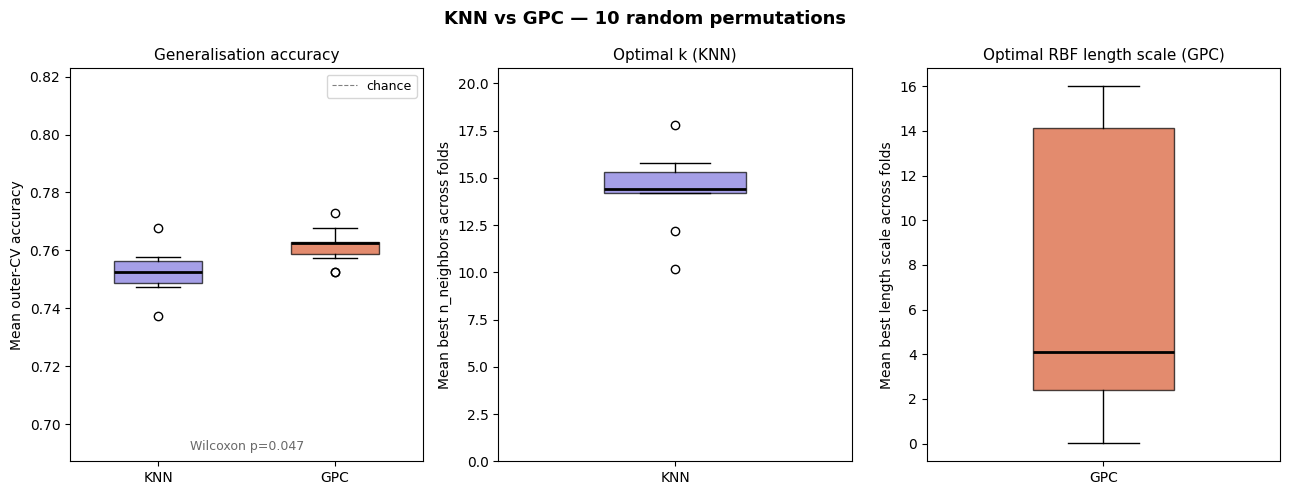

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("KNN vs GPC — 10 random permutations", fontsize=13, fontweight="bold")

# Plot 1: Model accuracy 
ax = axes[0]
bp = ax.boxplot(
    [knn_accs, gpc_accs],
    labels=["KNN", "GPC"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    widths=0.5,
)
colors = ["#7F77DD", "#D85A30"]           # purple / coral
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Generalisation accuracy", fontsize=11)
ax.set_ylabel("Mean outer-CV accuracy")
ax.set_ylim(
    max(0, min(knn_accs.min(), gpc_accs.min()) - 0.05),
    min(1, max(knn_accs.max(), gpc_accs.max()) + 0.05),
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance")
ax.legend(fontsize=9)
ax.text(0.5, 0.02, f"Wilcoxon p={p:.3f}",
        ha="center", va="bottom", transform=ax.transAxes,
        fontsize=9, color="dimgray")

# Plot 2: KNN - optimal k  
ax = axes[1]
bp2 = ax.boxplot(
    [knn_ks],
    labels=["KNN"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    widths=0.4,
)
bp2["boxes"][0].set_facecolor("#7F77DD")
bp2["boxes"][0].set_alpha(0.7)
ax.set_title("Optimal k (KNN)", fontsize=11)
ax.set_ylabel("Mean best n_neighbors across folds")
ax.set_ylim(0, max(knn_ks) + 3)

# Plot 3: GPC - optimal length scale 
ax = axes[2]
bp3 = ax.boxplot(
    [gpc_ls],
    labels=["GPC"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    widths=0.4,
)
bp3["boxes"][0].set_facecolor("#D85A30")
bp3["boxes"][0].set_alpha(0.7)
ax.set_title("Optimal RBF length scale (GPC)", fontsize=11)
ax.set_ylabel("Mean best length scale across folds")
        

plt.tight_layout()
plt.savefig("knn_vs_gpc_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## Exploratory visualization

### K-means clustering

In [ ]:
## BIC!
k = len(np.unique(yt)) 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(Xt)
cluster_centers = kmeans.cluster_centers_  # shape: (k, n_features)

### Kernel PCA projection

In [ ]:
#reverse mapping - careful!
kpca = KernelPCA(n_components=2, kernel='rbf', fit_inverse_transform=True, random_state=42)
Xt_kpca = kpca.fit_transform(Xt)                        # project data
centers_kpca = kpca.transform(cluster_centers)          # project cluster centers

#### Visualization of true clusters and K-means clusters

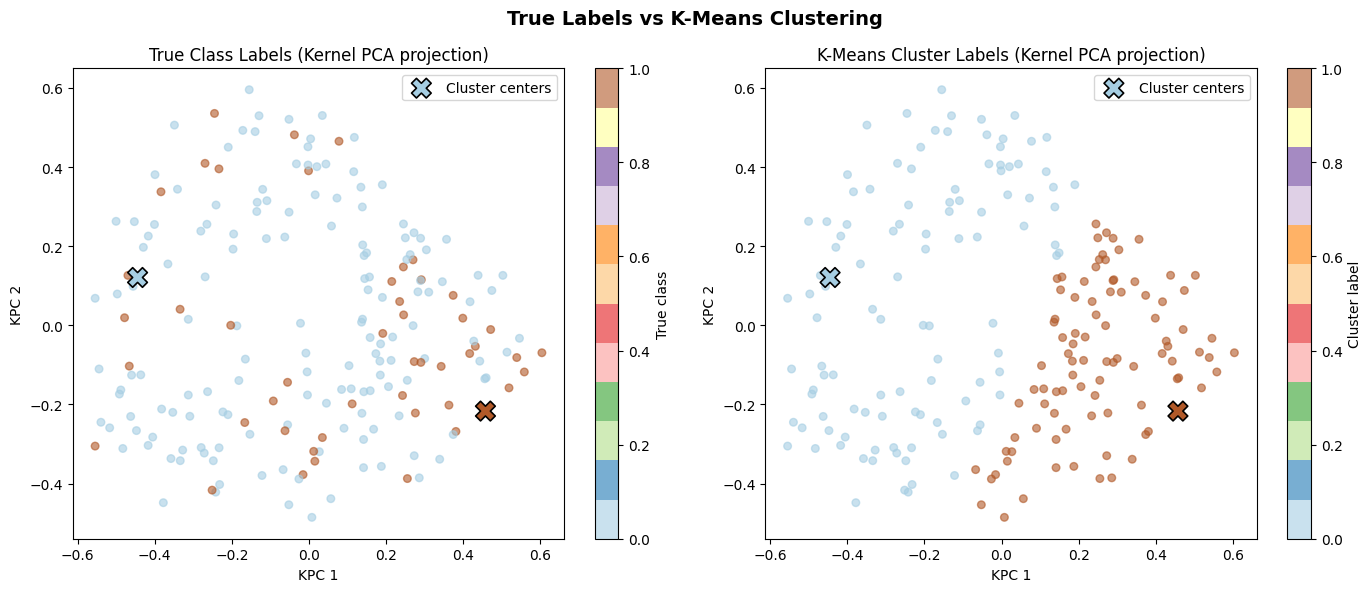

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# plot true class labels
sc1 = axes[0].scatter(
    Xt_kpca[:, 0], Xt_kpca[:, 1],
    c=yt,
    cmap='Paired',
    alpha=0.6,
    s=30
)
axes[0].scatter(
    centers_kpca[:, 0], centers_kpca[:, 1],
    c=range(k),
    cmap='Paired',
    s=200,
    marker='X',
    edgecolors='black',
    linewidths=1.2,
    zorder=5,
    label='Cluster centers'
)
axes[0].set_title('True Class Labels (Kernel PCA projection)')
axes[0].set_xlabel('KPC 1')
axes[0].set_ylabel('KPC 2')
plt.colorbar(sc1, ax=axes[0], label='True class')
axes[0].legend()

# plot K-means clusters
sc2 = axes[1].scatter(
    Xt_kpca[:, 0], Xt_kpca[:, 1],
    c=cluster_labels,
    cmap='Paired',
    alpha=0.6,
    s=30
)
axes[1].scatter(
    centers_kpca[:, 0], centers_kpca[:, 1],
    c=range(k),
    cmap='Paired',
    s=200,
    marker='X',
    edgecolors='black',
    linewidths=1.2,
    zorder=5,
    label='Cluster centers'
)
axes[1].set_title('K-Means Cluster Labels (Kernel PCA projection)')
axes[1].set_xlabel('KPC 1')
axes[1].set_ylabel('KPC 2')
plt.colorbar(sc2, ax=axes[1], label='Cluster label')
axes[1].legend()

plt.suptitle('True Labels vs K-Means Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### K-means accuracy calculation

In [21]:
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(true_labels, cluster_labels):
    k = len(np.unique(true_labels))
    
    # build a confusion matrix: rows = true classes, cols = cluster labels
    conf_matrix = np.zeros((k, k), dtype=int)
    for t, c in zip(true_labels, cluster_labels):
        conf_matrix[t, c] += 1
    
    # Hungarian algorithm finds the best label assignment
    row_ind, col_ind = linear_sum_assignment(-conf_matrix)  # maximize matches
    
    # count correctly assigned samples
    correct = conf_matrix[row_ind, col_ind].sum()
    accuracy = correct / len(true_labels)
    
    return accuracy, conf_matrix, col_ind

acc, conf, mapping = cluster_accuracy(yt, cluster_labels)
print(f"Cluster accuracy: {acc:.4f} ({acc*100:.2f}%)")

Cluster accuracy: 0.5960 (59.60%)
